# Tier 2 — Notebook A (v3 + FS): Australian Credit (UCI 143)

**v3 architecture audience-ready notebook.** Same template as the German v3+FS notebook.

**Architecture:**
- **5 base classifiers** (v3 lineup, no skew kernels): RF, GB, XGB, KNN, SVM-RBF.
- **5 meta candidates** (v3 lineup): LR, RF, XGB, MLP, GA-MaxAccLogit.
- **Feature-selection sweep retained** (Full / RFE / Lasso-LR / Forward).

**Dataset:** UCI 143 — Australian Credit Approval (n=690, 14 numeric features).

**Balanced** (44.57% positive) → `is_imbalanced=False` → no SMOTE, threshold = 0.5.

## §0  Environment setup

In [1]:
import os, sys
from pathlib import Path

DRIVE_PROJECT_PATH = '/content/drive/MyDrive/CreditRiskApp'

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
    print('Detected Google Colab.')
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path(DRIVE_PROJECT_PATH)
    PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
except ImportError:
    IN_COLAB = False
    print('Detected local environment.')
    NB_DIR = Path.cwd()
    PROJECT_ROOT = NB_DIR.parents[1] if NB_DIR.name == 'notebooks' else NB_DIR

RESULTS_DIR = PROJECT_ROOT / 'tier2_predictive_models' / 'results'
SUBSETS_DIR = PROJECT_ROOT / 'tier2_predictive_models' / 'fs_subsets'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SUBSETS_DIR.mkdir(parents=True, exist_ok=True)
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'RESULTS_DIR  = {RESULTS_DIR}')
print(f'SUBSETS_DIR  = {SUBSETS_DIR}')

Detected Google Colab.
Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/CreditRiskApp
RESULTS_DIR  = /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/results
SUBSETS_DIR  = /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets


### Configuration

In [2]:
DATASET       = 'australian'
UCI_ID        = 143
USE_SMOTE     = False  # balanced -> no SMOTE wrapping
RANDOM_STATE  = 42
CV_FOLDS      = 5
N_ITER_BAYES  = 25
SMOTE_K       = 5

# Tag prefix for every CSV this notebook saves
RUN_TAG       = 'australian_v3'

print(f"Dataset: {DATASET} (UCI id={UCI_ID})")
print(f"USE_SMOTE: {USE_SMOTE}  CV folds: {CV_FOLDS}  Bayes iter: {N_ITER_BAYES}")
print(f"RUN_TAG: {RUN_TAG}")

Dataset: australian (UCI id=143)
USE_SMOTE: False  CV folds: 5  Bayes iter: 25
RUN_TAG: australian_v3


### Install dependencies

In [3]:
!pip install ucimlrepo xgboost imbalanced-learn ghostml scikit-optimize -q
print('Libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.7 MB/s eta 0:00:00
Libraries installed!


### Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, cohen_kappa_score
from sklearn.base import BaseEstimator, ClassifierMixin

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import RFE, SelectFromModel, SequentialFeatureSelector
from xgboost import XGBClassifier
import ghostml

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from skopt import BayesSearchCV
from skopt.space import Real, Integer

print('Imports done.')

Imports done.


### Custom class — `MaxAccLogit`

Genetic-algorithm-tuned logistic regression. Used as one of the 5 meta candidates in the Stacker.
**No skew kernel classes here** — this is the v3 architecture without `SkewPNN` / `SkewSVM`.

In [5]:
class MaxAccLogit(BaseEstimator, ClassifierMixin):
    def __init__(self, lambda_reg=0.01, pop_size=None, n_gen=300,
                 p_crossover=0.8, p_mutation=0.1, elite_frac=0.05,
                 bound=3.0, early_stop=50, scoring='f1_macro', random_state=42):
        self.lambda_reg, self.pop_size, self.n_gen = lambda_reg, pop_size, n_gen
        self.p_crossover, self.p_mutation, self.elite_frac = p_crossover, p_mutation, elite_frac
        self.bound, self.early_stop, self.scoring = bound, early_stop, scoring
        self.random_state = random_state
    def _sigmoid(self, z): return 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))
    def _predict_with(self, theta, X): return self._sigmoid(X @ theta[1:] + theta[0])
    def _fitness(self, theta, X, y):
        prob = self._predict_with(theta, X); pred = (prob >= 0.5).astype(int)
        s = f1_score(y, pred, average='macro') if self.scoring == 'f1_macro' else accuracy_score(y, pred)
        return s - self.lambda_reg * np.abs(theta[1:]).sum()
    def _soft_threshold(self, theta):
        b0, b = theta[0], theta[1:]
        b = np.sign(b) * np.maximum(np.abs(b) - self.lambda_reg, 0.0)
        return np.concatenate([[b0], b])
    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X = np.asarray(X, dtype=float); y = np.asarray(y, dtype=int)
        n, p = X.shape; chrom_len = p + 1
        pop_size = self.pop_size if self.pop_size else 10 * chrom_len
        n_elite = max(1, int(self.elite_frac * pop_size))
        pop = rng.uniform(-self.bound, self.bound, size=(pop_size, chrom_len))
        for i in range(pop_size): pop[i] = self._soft_threshold(pop[i])
        fit_arr = np.array([self._fitness(t, X, y) for t in pop])
        best_history, no_improve = [], 0
        for gen in range(self.n_gen):
            f_min, f_max, f_mean = fit_arr.min(), fit_arr.max(), fit_arr.mean()
            C = 2.0; denom = f_max - f_mean if f_max != f_mean else 1e-10
            if f_min > (C * f_mean - f_max) / max(C - 1, 1e-10):
                a = f_mean * (C - 1) / denom
                b = f_mean * (f_max - C * f_mean) / denom
            else:
                d = f_mean - f_min if f_mean != f_min else 1e-10
                a = f_mean / d; b = -f_mean * f_min / d
            scaled = np.maximum(a * fit_arr + b, 1e-10)
            probs = scaled / scaled.sum()
            sel = rng.choice(pop_size, size=pop_size, p=probs)
            mating = pop[sel].copy()
            for i in range(0, pop_size - 1, 2):
                if rng.random() < self.p_crossover:
                    w = rng.uniform(0, 1, size=chrom_len)
                    p1, p2 = mating[i].copy(), mating[i+1].copy()
                    mating[i]   = w * p1 + (1 - w) * p2
                    mating[i+1] = (1 - w) * p1 + w * p2
            for i in range(pop_size):
                if rng.random() < self.p_mutation:
                    j = rng.integers(0, chrom_len)
                    mating[i, j] = rng.uniform(-self.bound, self.bound)
            for i in range(pop_size):
                mating[i] = self._soft_threshold(mating[i])
            new_fit = np.array([self._fitness(t, X, y) for t in mating])
            elite_idx_old = np.argsort(fit_arr)[-n_elite:]
            worst_idx_new = np.argsort(new_fit)[:n_elite]
            mating[worst_idx_new]  = pop[elite_idx_old]
            new_fit[worst_idx_new] = fit_arr[elite_idx_old]
            pop, fit_arr = mating, new_fit
            best = fit_arr.max(); best_history.append(best)
            if len(best_history) > 1 and best <= best_history[-2] + 1e-8:
                no_improve += 1
                if no_improve >= self.early_stop: break
            else:
                no_improve = 0
        best_idx = np.argmax(fit_arr)
        self.theta_, self.fitness_ = pop[best_idx], fit_arr[best_idx]
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = p
        return self
    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        prob = self._predict_with(self.theta_, X)
        return np.column_stack([1 - prob, prob])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print('MaxAccLogit class ready.')

MaxAccLogit class ready.


### `wrap_smote()` helper — applied conditionally
`wrap_smote(model)` returns `ImbPipeline(SMOTE -> model)`. Used everywhere when `USE_SMOTE=True`; otherwise the model is used as-is.

In [6]:
def wrap_smote(model, k=SMOTE_K, rs=RANDOM_STATE):
    """ImbPipeline(SMOTE -> clf). SMOTE fires only on .fit(), not on .predict()."""
    return ImbPipeline([
        ('smote', SMOTE(k_neighbors=k, random_state=rs)),
        ('clf',   model),
    ])

def maybe_smote(model):
    """Wrap in SMOTE if USE_SMOTE else pass through."""
    return wrap_smote(model) if USE_SMOTE else model

print(f'wrap_smote() ready.  USE_SMOTE = {USE_SMOTE}')

wrap_smote() ready.  USE_SMOTE = False


### Tiny CSV-save helper
Every CSV save goes through this so we have one place to also trigger a browser download in Colab.

In [7]:
def save_csv(df, path, also_download=True):
    """Save df to `path` and (optionally, only on Colab) trigger a browser download."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f'  Saved -> {path}  ({len(df)} rows, {df.shape[1]} cols)')
    if also_download and IN_COLAB:
        try:
            from google.colab import files
            files.download(str(path))
        except Exception as e:
            print(f'  (skipped browser download: {e.__class__.__name__})')

print('save_csv() ready.')

save_csv() ready.


## §1  Data preprocessing

Every step is in its own cell so anything that breaks can be inspected in isolation.

### Step 1 — Load

In [8]:
ds = fetch_ucirepo(id=UCI_ID)
X_raw = ds.data.features.copy()
y_raw = ds.data.targets.copy()
print(f"Raw shape: X = {X_raw.shape},  y = {y_raw.shape}")
print('First 5 rows of X:')
X_raw.head()

Raw shape: X = (690, 14),  y = (690, 1)
First 5 rows of X:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159


### Step 2 — Encode target + check class balance

In [9]:
y_flat = y_raw.iloc[:, 0].astype(int).values  # UCI 143: already 0/1 (1 = approved)
pos_rate = y_flat.mean()
imbalance = abs(pos_rate - 0.5)
is_imbalanced = imbalance > 0.10
print(f'Positives (1=approved): {y_flat.sum()}/{len(y_flat)} = {pos_rate:.2%}')
print(f'Imbalance |pos - 0.5| = {imbalance:.2%}')
print(f'is_imbalanced = {is_imbalanced}  ->  SMOTE: {"ON" if USE_SMOTE else "OFF"}')

Positives (1=approved): 307/690 = 44.49%
Imbalance |pos - 0.5| = 5.51%
is_imbalanced = False  ->  SMOTE: OFF


### Step 3 — Missing-value handling

In [10]:
cat_cols = X_raw.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns:     {len(num_cols)}')
print(f'Categorical columns: {len(cat_cols)}')
print(f'Total missing values before fill: {X_raw.isna().sum().sum()}')

for c in num_cols:
    if X_raw[c].isna().any():
        X_raw[c] = X_raw[c].fillna(X_raw[c].median())
for c in cat_cols:
    if X_raw[c].isna().any():
        mode = X_raw[c].mode()
        X_raw[c] = X_raw[c].fillna(mode[0] if not mode.empty else 'MISSING')
print(f'Total missing values after fill:  {X_raw.isna().sum().sum()}')

Numeric columns:     14
Categorical columns: 0
Total missing values before fill: 0
Total missing values after fill:  0


### Step 4 — One-hot encode categorical columns

In [11]:
if cat_cols:
    X_enc = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
    print(f'After one-hot: {X_raw.shape[1]} -> {X_enc.shape[1]} columns')
else:
    X_enc = X_raw.copy()
    print(f'No categorical columns to encode. Columns: {X_enc.shape[1]}')

No categorical columns to encode. Columns: 14


### Step 5 — Standard-scale all features

In [12]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_enc.astype(float)), columns=X_enc.columns)
print(f'After scaling: mean={X_scaled.values.mean():.4f}, std={X_scaled.values.std():.4f}')
feat_names = X_scaled.columns.tolist()
print(f'Total features after preprocessing: {len(feat_names)}')

After scaling: mean=0.0000, std=1.0000
Total features after preprocessing: 14


### Step 6 — Stratified 80/20 train/test split

In [13]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_scaled, y_flat, test_size=0.2, random_state=RANDOM_STATE, stratify=y_flat
)
X_train = X_train_df.values
X_test  = X_test_df.values
print(f'X_train: {X_train.shape}   y_train pos rate: {y_train.mean():.2%}')
print(f'X_test:  {X_test.shape}    y_test  pos rate: {y_test.mean():.2%}')
print(f'Total features: {len(feat_names)}')

X_train: (552, 14)   y_train pos rate: 44.57%
X_test:  (138, 14)    y_test  pos rate: 44.20%
Total features: 14


## §2  Feature-selection sweep — produces 4 sub-datasets

For every FS variant we:
1. Compute the selected feature indices.
2. Print the **full list** of selected features.
3. Build the FS-restricted (X_train, X_test) subset.
4. Save the subset as **one CSV** with a `split` column (`train` / `test`) and the target column appended.
5. Save the feature list as a separate CSV.

After this section we have **4 sub-datasets for Australian Credit**. Combined with the other 3 UCI datasets, that's **16 sub-datasets total**.

### Helper — `materialize_subset()`

In [14]:
def materialize_subset(fs_name, fs_idx):
    cols = [feat_names[i] for i in fs_idx]
    print(f'--- FS = {fs_name}  ({len(cols)} features) ---')
    print('Selected feature names:')
    for j, c in enumerate(cols, 1):
        print(f'  {j:2d}. {c}')

    Xtr_df = X_train_df.iloc[:, fs_idx].copy()
    Xte_df = X_test_df.iloc[:, fs_idx].copy()
    Xtr_df['_split'] = 'train';  Xtr_df['_target'] = y_train
    Xte_df['_split'] = 'test';   Xte_df['_target'] = y_test
    subset_df = pd.concat([Xtr_df, Xte_df], axis=0, ignore_index=True)

    subset_path = SUBSETS_DIR / f'{RUN_TAG}_FS_{fs_name.replace("-", "_")}.csv'
    save_csv(subset_df, subset_path, also_download=False)

    feats_df = pd.DataFrame({'idx': fs_idx, 'feature': cols})
    feats_path = SUBSETS_DIR / f'{RUN_TAG}_FS_{fs_name.replace("-", "_")}_features.csv'
    save_csv(feats_df, feats_path, also_download=False)

    return cols, subset_path, feats_path

print('materialize_subset() ready.')

materialize_subset() ready.


### FS variant 1 — Full (all features)

In [15]:
def fs_full(X, y): return np.arange(X.shape[1])

idx_full = fs_full(X_train, y_train)
cols_full, sub_full, feat_full = materialize_subset('Full', idx_full)

--- FS = Full  (14 features) ---
Selected feature names:
   1. A1
   2. A2
   3. A3
   4. A4
   5. A5
   6. A6
   7. A7
   8. A8
   9. A9
  10. A10
  11. A11
  12. A12
  13. A13
  14. A14
  Saved -> /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_Full.csv  (690 rows, 16 cols)
  Saved -> /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_Full_features.csv  (14 rows, 2 cols)


### FS variant 2 — RFE (RandomForest-wrapped)

In [16]:
def fs_rfe(X, y):
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    rfe = RFE(rf); rfe.fit(X, y)
    return np.where(rfe.support_)[0]

idx_rfe = fs_rfe(X_train, y_train)
cols_rfe, sub_rfe, feat_rfe = materialize_subset('RFE', idx_rfe)

--- FS = RFE  (7 features) ---
Selected feature names:
   1. A2
   2. A3
   3. A5
   4. A7
   5. A8
   6. A10
   7. A14
  Saved -> /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_RFE.csv  (690 rows, 9 cols)
  Saved -> /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_RFE_features.csv  (7 rows, 2 cols)


### FS variant 3 — Lasso-LR (L1 logistic regression)

In [17]:
def fs_lasso_lr(X, y):
    lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=RANDOM_STATE)
    sel = SelectFromModel(lasso); sel.fit(X, y)
    return np.where(sel.get_support())[0]

idx_lasso = fs_lasso_lr(X_train, y_train)
cols_lasso, sub_lasso, feat_lasso = materialize_subset('Lasso-LR', idx_lasso)

--- FS = Lasso-LR  (12 features) ---
Selected feature names:
   1. A1
   2. A2
   3. A3
   4. A4
   5. A5
   6. A7
   7. A8
   8. A10
   9. A11
  10. A12
  11. A13
  12. A14
  Saved -> /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_Lasso_LR.csv  (690 rows, 14 cols)
  Saved -> /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_Lasso_LR_features.csv  (12 rows, 2 cols)


### FS variant 4 — Forward (Sequential, LR estimator)

In [18]:
def fs_forward(X, y):
    lr = LogisticRegression(solver='newton-cg', max_iter=500, random_state=RANDOM_STATE)
    sel = SequentialFeatureSelector(lr, direction='forward', n_jobs=-1)
    sel.fit(X, y)
    return np.where(sel.support_)[0]

idx_forward = fs_forward(X_train, y_train)
cols_forward, sub_forward, feat_forward = materialize_subset('Forward', idx_forward)

--- FS = Forward  (7 features) ---
Selected feature names:
   1. A1
   2. A2
   3. A3
   4. A5
   5. A8
   6. A12
   7. A13
  Saved -> /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_Forward.csv  (690 rows, 9 cols)
  Saved -> /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_Forward_features.csv  (7 rows, 2 cols)


### Summary — 4 sub-datasets ready

In [19]:
fs_methods = {
    'Full'     : idx_full,
    'RFE'      : idx_rfe,
    'Lasso-LR' : idx_lasso,
    'Forward'  : idx_forward,
}
fs_summary = pd.DataFrame([
    {'FS': name, 'n_features': len(idx), 'features': ', '.join([feat_names[i] for i in idx])}
    for name, idx in fs_methods.items()
])
print('=' * 70); print('  FS sweep summary'); print('=' * 70)
print(fs_summary[['FS', 'n_features']].to_string(index=False))
print('=' * 70)
save_csv(fs_summary, SUBSETS_DIR / f'{RUN_TAG}_FS_summary.csv', also_download=False)

  FS sweep summary
      FS  n_features
    Full          14
     RFE           7
Lasso-LR          12
 Forward           7
  Saved -> /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_summary.csv  (4 rows, 3 cols)


---

### Evaluation helpers

In [20]:
GHOST_THR = np.round(np.arange(0.05, 0.95, 0.01), 2)
USE_GHOST = USE_SMOTE

def evaluate(model, X_tr, X_te, y_tr, y_te):
    """Fit on (X_tr, y_tr); predict on X_te; return Acc / F1 / F1-macro / AUC / thr."""
    model.fit(X_tr, y_tr)
    proba_test = model.predict_proba(X_te)[:, 1]
    if USE_GHOST:
        proba_train = model.predict_proba(X_tr)[:, 1]
        thr = ghostml.optimize_threshold_from_predictions(
            y_tr, proba_train, GHOST_THR, ThOpt_metrics='Kappa')
    else:
        thr = 0.5
    pred = (proba_test >= thr).astype(int)
    return dict(
        acc      = accuracy_score(y_te, pred),
        f1       = f1_score(y_te, pred),
        f1_macro = f1_score(y_te, pred, average='macro'),
        auc      = roc_auc_score(y_te, proba_test),
        thr      = thr,
    )

def sweep_single_model(model_factory, name, category):
    """Run one model_factory across all 4 FS variants."""
    rows = []
    for fs_name, fs_idx in fs_methods.items():
        Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
        r = evaluate(model_factory(), Xtr, Xte, y_train, y_test)
        r.update(model=name, category=category, fs=fs_name, n_features=len(fs_idx))
        rows.append(r)
        print(f'  [{category}] {name:<14s} | FS={fs_name:<8s} | '
              f'F1-macro={r["f1_macro"]:.4f}  Acc={r["acc"]:.4f}  F1={r["f1"]:.4f}  thr={r["thr"]:.2f}')
    return rows

print(f'Helpers ready.  USE_GHOST = {USE_GHOST}')

Helpers ready.  USE_GHOST = False


## §3  Base models — simple classifiers

| Model | What it is |
|---|---|
| LogisticRegression | Linear classifier, L2 regularisation. |
| KNN (k=13, Manhattan) | k-nearest neighbours with Manhattan distance. |
| SVM (RBF) | Support vector machine with radial basis function kernel. |
| DecisionTree | Single tree, `max_depth=5`. |

### §3.1 — LogisticRegression × 4 FS

In [21]:
base_lr = sweep_single_model(
    lambda: maybe_smote(LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
    name='LogisticReg', category='Base'
)

  [Base] LogisticReg    | FS=Full     | F1-macro=0.8333  Acc=0.8333  F1=0.8321  thr=0.50
  [Base] LogisticReg    | FS=RFE      | F1-macro=0.8333  Acc=0.8333  F1=0.8321  thr=0.50
  [Base] LogisticReg    | FS=Lasso-LR | F1-macro=0.8333  Acc=0.8333  F1=0.8321  thr=0.50
  [Base] LogisticReg    | FS=Forward  | F1-macro=0.7971  Acc=0.7971  F1=0.8000  thr=0.50


### §3.2 — KNN × 4 FS

In [22]:
base_knn = sweep_single_model(
    lambda: maybe_smote(KNeighborsClassifier(n_neighbors=13, metric='manhattan')),
    name='KNN', category='Base'
)

  [Base] KNN            | FS=Full     | F1-macro=0.8526  Acc=0.8551  F1=0.8333  thr=0.50
  [Base] KNN            | FS=RFE      | F1-macro=0.8258  Acc=0.8261  F1=0.8182  thr=0.50
  [Base] KNN            | FS=Lasso-LR | F1-macro=0.8026  Acc=0.8043  F1=0.7840  thr=0.50
  [Base] KNN            | FS=Forward  | F1-macro=0.8116  Acc=0.8116  F1=0.8116  thr=0.50


### §3.3 — SVM (RBF) × 4 FS

In [23]:
base_svm = sweep_single_model(
    lambda: maybe_smote(SVC(C=10.0, kernel='rbf', gamma='scale',
                            probability=True, random_state=RANDOM_STATE)),
    name='SVM-RBF', category='Base'
)

  [Base] SVM-RBF        | FS=Full     | F1-macro=0.8326  Acc=0.8333  F1=0.8217  thr=0.50
  [Base] SVM-RBF        | FS=RFE      | F1-macro=0.8333  Acc=0.8333  F1=0.8296  thr=0.50
  [Base] SVM-RBF        | FS=Lasso-LR | F1-macro=0.8329  Acc=0.8333  F1=0.8244  thr=0.50
  [Base] SVM-RBF        | FS=Forward  | F1-macro=0.7824  Acc=0.7826  F1=0.7761  thr=0.50


### §3.4 — DecisionTree × 4 FS

In [24]:
base_dt = sweep_single_model(
    lambda: maybe_smote(DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    name='DecisionTree', category='Base'
)

  [Base] DecisionTree   | FS=Full     | F1-macro=0.8090  Acc=0.8116  F1=0.7869  thr=0.50
  [Base] DecisionTree   | FS=RFE      | F1-macro=0.7967  Acc=0.7971  F1=0.7879  thr=0.50
  [Base] DecisionTree   | FS=Lasso-LR | F1-macro=0.8248  Acc=0.8261  F1=0.8095  thr=0.50
  [Base] DecisionTree   | FS=Forward  | F1-macro=0.8261  Acc=0.8261  F1=0.8235  thr=0.50


### §3.5 — Base-model results table + save CSV

In [25]:
base_results = base_lr + base_knn + base_svm + base_dt
df_base = pd.DataFrame(base_results)[
    ['category', 'model', 'fs', 'n_features', 'acc', 'f1', 'f1_macro', 'auc', 'thr']
]
df_base.columns = ['Category', 'Model', 'FS', 'n_feat', 'Accuracy', 'F1', 'F1-macro', 'AUC', 'thr']
for c in ['Accuracy', 'F1', 'F1-macro', 'AUC']: df_base[c] = df_base[c].round(4)
df_base['thr'] = df_base['thr'].round(2)
print('=' * 88); print('  §3 BASE MODELS — 4 classifiers x 4 FS = 16 rows'); print('=' * 88)
print(df_base.to_string(index=False))
save_csv(df_base, RESULTS_DIR / f'{RUN_TAG}_base_results.csv')

  §3 BASE MODELS — 4 classifiers x 4 FS = 16 rows
Category        Model       FS  n_feat  Accuracy     F1  F1-macro    AUC  thr
    Base  LogisticReg     Full      14    0.8333 0.8321    0.8333 0.9140  0.5
    Base  LogisticReg      RFE       7    0.8333 0.8321    0.8333 0.9231  0.5
    Base  LogisticReg Lasso-LR      12    0.8333 0.8321    0.8333 0.9136  0.5
    Base  LogisticReg  Forward       7    0.7971 0.8000    0.7971 0.8456  0.5
    Base          KNN     Full      14    0.8551 0.8333    0.8526 0.9074  0.5
    Base          KNN      RFE       7    0.8261 0.8182    0.8258 0.8890  0.5
    Base          KNN Lasso-LR      12    0.8043 0.7840    0.8026 0.8900  0.5
    Base          KNN  Forward       7    0.8116 0.8116    0.8116 0.8510  0.5
    Base      SVM-RBF     Full      14    0.8333 0.8217    0.8326 0.8765  0.5
    Base      SVM-RBF      RFE       7    0.8333 0.8296    0.8333 0.8933  0.5
    Base      SVM-RBF Lasso-LR      12    0.8333 0.8244    0.8329 0.8699  0.5
    Base      

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## §5  Ensemble models  (v3 architecture — no skew kernels)

### 5a — Classical ensembles (RF, GB, XGB)
RF and XGB are Bayesian-tuned (25 iter x 5-fold CV, scored on `f1_macro`); GB uses sensible defaults.

### 5b — The Stacker (v3)
**5 base classifiers**: RF, GB, XGB, KNN, SVM-RBF.
**5 meta candidates**: LR, RF, XGB, MLP, GA-MaxAccLogit.

### §5a-1 — Bayesian tuning helpers for RF and XGB

In [26]:
def tune_rf(X, y):
    s = BayesSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': Integer(100, 500),
         'max_depth': Integer(3, 20),
         'min_samples_split': Integer(2, 10),
         'max_features': Real(0.3, 0.9)},
        n_iter=N_ITER_BAYES, cv=CV_FOLDS, scoring='f1_macro',
        n_jobs=-1, random_state=RANDOM_STATE)
    s.fit(X, y); return s.best_estimator_

def tune_xgb(X, y):
    s = BayesSearchCV(
        XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
        {'n_estimators': Integer(100, 400),
         'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
         'max_depth': Integer(3, 8),
         'subsample': Real(0.6, 1.0),
         'colsample_bytree': Real(0.6, 1.0)},
        n_iter=N_ITER_BAYES, cv=CV_FOLDS, scoring='f1_macro',
        n_jobs=-1, random_state=RANDOM_STATE)
    s.fit(X, y); return s.best_estimator_

print('tune_rf() and tune_xgb() ready.')

tune_rf() and tune_xgb() ready.


### §5a-2 — Tune RF + XGB once per FS variant
Cached for reuse in §5b Stacker.

In [27]:
tuned_rf  = {fs: tune_rf (X_train[:, idx], y_train) for fs, idx in fs_methods.items()}
tuned_xgb = {fs: tune_xgb(X_train[:, idx], y_train) for fs, idx in fs_methods.items()}
print('Tuned RF + XGB cached for every FS variant.')

Tuned RF + XGB cached for every FS variant.


### §5a-3 — RandomForest (tuned) × 4 FS

In [28]:
ens_rf = []
for fs_name, fs_idx in fs_methods.items():
    Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
    r = evaluate(tuned_rf[fs_name], Xtr, Xte, y_train, y_test)
    r.update(model='RandomForest', category='Ensemble', fs=fs_name, n_features=len(fs_idx))
    ens_rf.append(r)
    print(f'  [Ensemble] RandomForest   | FS={fs_name:<8s} | '
          f'F1-macro={r["f1_macro"]:.4f}  Acc={r["acc"]:.4f}  F1={r["f1"]:.4f}  thr={r["thr"]:.2f}')

  [Ensemble] RandomForest   | FS=Full     | F1-macro=0.8188  Acc=0.8188  F1=0.8148  thr=0.50
  [Ensemble] RandomForest   | FS=RFE      | F1-macro=0.8186  Acc=0.8188  F1=0.8120  thr=0.50
  [Ensemble] RandomForest   | FS=Lasso-LR | F1-macro=0.8116  Acc=0.8116  F1=0.8088  thr=0.50
  [Ensemble] RandomForest   | FS=Forward  | F1-macro=0.8188  Acc=0.8188  F1=0.8148  thr=0.50


### §5a-4 — GradientBoosting (defaults) × 4 FS

In [29]:
ens_gb = sweep_single_model(
    lambda: maybe_smote(GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE)),
    name='GradBoost', category='Ensemble'
)

  [Ensemble] GradBoost      | FS=Full     | F1-macro=0.8548  Acc=0.8551  F1=0.8485  thr=0.50
  [Ensemble] GradBoost      | FS=RFE      | F1-macro=0.8331  Acc=0.8333  F1=0.8271  thr=0.50
  [Ensemble] GradBoost      | FS=Lasso-LR | F1-macro=0.8474  Acc=0.8478  F1=0.8397  thr=0.50
  [Ensemble] GradBoost      | FS=Forward  | F1-macro=0.8181  Acc=0.8188  F1=0.8062  thr=0.50


### §5a-5 — XGBoost (tuned) × 4 FS

In [30]:
ens_xgb = []
for fs_name, fs_idx in fs_methods.items():
    Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
    r = evaluate(tuned_xgb[fs_name], Xtr, Xte, y_train, y_test)
    r.update(model='XGBoost', category='Ensemble', fs=fs_name, n_features=len(fs_idx))
    ens_xgb.append(r)
    print(f'  [Ensemble] XGBoost        | FS={fs_name:<8s} | '
          f'F1-macro={r["f1_macro"]:.4f}  Acc={r["acc"]:.4f}  F1={r["f1"]:.4f}  thr={r["thr"]:.2f}')

  [Ensemble] XGBoost        | FS=Full     | F1-macro=0.8689  Acc=0.8696  F1=0.8594  thr=0.50
  [Ensemble] XGBoost        | FS=RFE      | F1-macro=0.8329  Acc=0.8333  F1=0.8244  thr=0.50
  [Ensemble] XGBoost        | FS=Lasso-LR | F1-macro=0.8763  Acc=0.8768  F1=0.8682  thr=0.50
  [Ensemble] XGBoost        | FS=Forward  | F1-macro=0.8112  Acc=0.8116  F1=0.8030  thr=0.50


### §5a-6 — Classical ensembles table + save CSV

In [31]:
ens_results = ens_rf + ens_gb + ens_xgb
df_ens = pd.DataFrame(ens_results)[
    ['category', 'model', 'fs', 'n_features', 'acc', 'f1', 'f1_macro', 'auc', 'thr']
]
df_ens.columns = ['Category', 'Model', 'FS', 'n_feat', 'Accuracy', 'F1', 'F1-macro', 'AUC', 'thr']
for c in ['Accuracy', 'F1', 'F1-macro', 'AUC']: df_ens[c] = df_ens[c].round(4)
df_ens['thr'] = df_ens['thr'].round(2)
print('=' * 88); print('  §5a CLASSICAL ENSEMBLES — 3 classifiers x 4 FS = 12 rows'); print('=' * 88)
print(df_ens.to_string(index=False))
save_csv(df_ens, RESULTS_DIR / f'{RUN_TAG}_classical_ensembles_results.csv')

  §5a CLASSICAL ENSEMBLES — 3 classifiers x 4 FS = 12 rows
Category        Model       FS  n_feat  Accuracy     F1  F1-macro    AUC  thr
Ensemble RandomForest     Full      14    0.8188 0.8148    0.8188 0.9306  0.5
Ensemble RandomForest      RFE       7    0.8188 0.8120    0.8186 0.9176  0.5
Ensemble RandomForest Lasso-LR      12    0.8116 0.8088    0.8116 0.9295  0.5
Ensemble RandomForest  Forward       7    0.8188 0.8148    0.8188 0.8884  0.5
Ensemble    GradBoost     Full      14    0.8551 0.8485    0.8548 0.9244  0.5
Ensemble    GradBoost      RFE       7    0.8333 0.8271    0.8331 0.8987  0.5
Ensemble    GradBoost Lasso-LR      12    0.8478 0.8397    0.8474 0.9240  0.5
Ensemble    GradBoost  Forward       7    0.8188 0.8062    0.8181 0.8899  0.5
Ensemble      XGBoost     Full      14    0.8696 0.8594    0.8689 0.9385  0.5
Ensemble      XGBoost      RFE       7    0.8333 0.8244    0.8329 0.9226  0.5
Ensemble      XGBoost Lasso-LR      12    0.8768 0.8682    0.8763 0.9368  0.5
Ensem

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### §5b — The Stacker (v3, 5 bases × 5 metas)

### §5b-1 — `cv_best_lambda()` helper for GA-MaxAccLogit meta

In [32]:
def cv_best_lambda(X, y, lambda_grid, cv=5, n_gen=150, rs=RANDOM_STATE):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=rs)
    best_lam, best_score = lambda_grid[0], -np.inf
    for lam in lambda_grid:
        scores = []
        for tr, va in skf.split(X, y):
            mdl = maybe_smote(MaxAccLogit(lambda_reg=lam, n_gen=n_gen, scoring='f1_macro',
                                          random_state=rs)).fit(X[tr], y[tr])
            scores.append(f1_score(y[va], mdl.predict(X[va]), average='macro'))
        m = np.mean(scores)
        if m > best_score: best_score, best_lam = m, lam
    return best_lam

print('cv_best_lambda() ready.')

cv_best_lambda() ready.


### §5b-2 — `run_stacker_v3()` — one call per FS variant

In [33]:
USE_AUGMENTED_META = False   # if True, meta sees (X + base_probs); else just base_probs

def run_stacker_v3(Xtr, Xte, ytr, yte, fs_name):
    print(f'\n  -- Stacker @ FS={fs_name}  (5 bases x 5 metas)'
          f'{"  | augmented meta input (X + base_probs)" if USE_AUGMENTED_META else ""} --')
    base_models = {
        'RF'      : tuned_rf[fs_name],
        'GB'      : maybe_smote(GradientBoostingClassifier(
                       n_estimators=300, learning_rate=0.05, max_depth=5,
                       subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE)),
        'XGB'     : tuned_xgb[fs_name],
        'KNN'     : maybe_smote(KNeighborsClassifier(n_neighbors=13, metric='manhattan')),
        'SVM'     : maybe_smote(SVC(C=10.0, kernel='rbf', gamma='scale',
                                    probability=True, random_state=RANDOM_STATE)),
    }
    oof_cols, test_cols = [], []
    for bname, bmodel in base_models.items():
        oof = cross_val_predict(bmodel, Xtr, ytr, cv=CV_FOLDS, method='predict_proba')[:, 1]
        oof_cols.append(oof)
        bmodel.fit(Xtr, ytr)
        test_cols.append(bmodel.predict_proba(Xte)[:, 1])
        print(f'    base {bname:<5s}  OOF AUC={roc_auc_score(ytr, oof):.4f}  '
              f'test AUC={roc_auc_score(yte, test_cols[-1]):.4f}')

    oof_probs_only  = np.column_stack(oof_cols)
    test_probs_only = np.column_stack(test_cols)

    if USE_AUGMENTED_META:
        oof_probs  = np.column_stack([Xtr, oof_probs_only])
        test_probs = np.column_stack([Xte, test_probs_only])
        print(f'    augmented meta input shape: train={oof_probs.shape}, test={test_probs.shape}'
              f'   (= {Xtr.shape[1]} raw features + 5 base probs)')
    else:
        oof_probs  = oof_probs_only
        test_probs = test_probs_only

    best_lam = cv_best_lambda(oof_probs, ytr,
                              lambda_grid=[0.0005, 0.001, 0.002, 0.005, 0.01],
                              cv=5, n_gen=150)
    meta_models = {
        'LR'  : maybe_smote(LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
        'RF'  : maybe_smote(RandomForestClassifier(n_estimators=200, max_depth=5,
                                                   random_state=RANDOM_STATE)),
        'XGB' : maybe_smote(XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                          random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)),
        'MLP' : maybe_smote(MLPClassifier(hidden_layer_sizes=(64,32), activation='relu',
                                          alpha=0.001, max_iter=500, random_state=RANDOM_STATE)),
        'GA'  : maybe_smote(MaxAccLogit(lambda_reg=best_lam, n_gen=200,
                                        scoring='f1_macro', random_state=RANDOM_STATE)),
    }
    meta_scores = {}
    for mname, meta in meta_models.items():
        meta.fit(oof_probs, ytr)
        train_p = meta.predict_proba(oof_probs)[:, 1]
        proba   = meta.predict_proba(test_probs)[:, 1]
        thr = 0.5
        pred = (proba >= thr).astype(int)
        meta_scores[mname] = dict(
            acc=accuracy_score(yte, pred),
            f1 =f1_score(yte, pred),
            f1_macro=f1_score(yte, pred, average='macro'),
            auc=roc_auc_score(yte, proba),
            thr=thr,
        )
        s = meta_scores[mname]
        print(f'    meta {mname:<5s}  F1-macro={s["f1_macro"]:.4f}  '
              f'Acc={s["acc"]:.4f}  F1={s["f1"]:.4f}  AUC={s["auc"]:.4f}  thr={s["thr"]:.2f}')
    best_meta = max(meta_scores, key=lambda k: meta_scores[k]['f1_macro'])
    r = meta_scores[best_meta]
    r.update(model=f'Stacker ({best_meta})', category='Ensemble',
             fs=fs_name, n_features=Xtr.shape[1])
    print(f'    -> winning meta: {best_meta}  (F1-macro={r["f1_macro"]:.4f})')
    return r

print('run_stacker_v3() ready.')

run_stacker_v3() ready.


### §5b-3 — Stacker on FS = Full

In [34]:
Xtr = X_train[:, fs_methods['Full']]; Xte = X_test[:, fs_methods['Full']]
stacker_full = run_stacker_v3(Xtr, Xte, y_train, y_test, 'Full')


  -- Stacker @ FS=Full  (5 bases x 5 metas) --
    base RF     OOF AUC=0.9341  test AUC=0.9306
    base GB     OOF AUC=0.9305  test AUC=0.9244
    base XGB    OOF AUC=0.9372  test AUC=0.9385
    base KNN    OOF AUC=0.9231  test AUC=0.9074
    base SVM    OOF AUC=0.8965  test AUC=0.8765
    meta LR     F1-macro=0.8614  Acc=0.8623  F1=0.8504  AUC=0.9395  thr=0.50
    meta RF     F1-macro=0.8255  Acc=0.8261  F1=0.8154  AUC=0.9324  thr=0.50
    meta XGB    F1-macro=0.8258  Acc=0.8261  F1=0.8182  AUC=0.9280  thr=0.50
    meta MLP    F1-macro=0.8394  Acc=0.8406  F1=0.8254  AUC=0.9410  thr=0.50
    meta GA     F1-macro=0.8614  Acc=0.8623  F1=0.8504  AUC=0.9404  thr=0.50
    -> winning meta: LR  (F1-macro=0.8614)


### §5b-4 — Stacker on FS = RFE

In [35]:
Xtr = X_train[:, fs_methods['RFE']]; Xte = X_test[:, fs_methods['RFE']]
stacker_rfe = run_stacker_v3(Xtr, Xte, y_train, y_test, 'RFE')


  -- Stacker @ FS=RFE  (5 bases x 5 metas) --
    base RF     OOF AUC=0.9382  test AUC=0.9176
    base GB     OOF AUC=0.9251  test AUC=0.8987
    base XGB    OOF AUC=0.9366  test AUC=0.9226
    base KNN    OOF AUC=0.9201  test AUC=0.8890
    base SVM    OOF AUC=0.9081  test AUC=0.8933
    meta LR     F1-macro=0.8259  Acc=0.8261  F1=0.8209  AUC=0.9191  thr=0.50
    meta RF     F1-macro=0.8261  Acc=0.8261  F1=0.8235  AUC=0.9056  thr=0.50
    meta XGB    F1-macro=0.8184  Acc=0.8188  F1=0.8092  AUC=0.8908  thr=0.50
    meta MLP    F1-macro=0.8114  Acc=0.8116  F1=0.8060  AUC=0.9225  thr=0.50
    meta GA     F1-macro=0.8333  Acc=0.8333  F1=0.8345  AUC=0.9217  thr=0.50
    -> winning meta: GA  (F1-macro=0.8333)


### §5b-5 — Stacker on FS = Lasso-LR

In [36]:
Xtr = X_train[:, fs_methods['Lasso-LR']]; Xte = X_test[:, fs_methods['Lasso-LR']]
stacker_lasso_lr = run_stacker_v3(Xtr, Xte, y_train, y_test, 'Lasso-LR')


  -- Stacker @ FS=Lasso-LR  (5 bases x 5 metas) --
    base RF     OOF AUC=0.9405  test AUC=0.9295
    base GB     OOF AUC=0.9315  test AUC=0.9240
    base XGB    OOF AUC=0.9369  test AUC=0.9368
    base KNN    OOF AUC=0.9349  test AUC=0.8900
    base SVM    OOF AUC=0.9092  test AUC=0.8699
    meta LR     F1-macro=0.8403  Acc=0.8406  F1=0.8333  AUC=0.9323  thr=0.50
    meta RF     F1-macro=0.8259  Acc=0.8261  F1=0.8209  AUC=0.9182  thr=0.50
    meta XGB    F1-macro=0.8261  Acc=0.8261  F1=0.8235  AUC=0.9174  thr=0.50
    meta MLP    F1-macro=0.8259  Acc=0.8261  F1=0.8209  AUC=0.9259  thr=0.50
    meta GA     F1-macro=0.8323  Acc=0.8333  F1=0.8189  AUC=0.9327  thr=0.50
    -> winning meta: LR  (F1-macro=0.8403)


### §5b-6 — Stacker on FS = Forward

In [37]:
Xtr = X_train[:, fs_methods['Forward']]; Xte = X_test[:, fs_methods['Forward']]
stacker_forward = run_stacker_v3(Xtr, Xte, y_train, y_test, 'Forward')


  -- Stacker @ FS=Forward  (5 bases x 5 metas) --
    base RF     OOF AUC=0.9265  test AUC=0.8884
    base GB     OOF AUC=0.9123  test AUC=0.8899
    base XGB    OOF AUC=0.9264  test AUC=0.8835
    base KNN    OOF AUC=0.9198  test AUC=0.8510
    base SVM    OOF AUC=0.9018  test AUC=0.8461
    meta LR     F1-macro=0.8114  Acc=0.8116  F1=0.8060  AUC=0.8887  thr=0.50
    meta RF     F1-macro=0.7971  Acc=0.7971  F1=0.7941  AUC=0.8729  thr=0.50
    meta XGB    F1-macro=0.8043  Acc=0.8043  F1=0.8000  AUC=0.8530  thr=0.50
    meta MLP    F1-macro=0.8114  Acc=0.8116  F1=0.8060  AUC=0.8880  thr=0.50
    meta GA     F1-macro=0.8116  Acc=0.8116  F1=0.8088  AUC=0.8912  thr=0.50
    -> winning meta: GA  (F1-macro=0.8116)


### §5b-7 — Stacker results table + save CSV

In [38]:
stacker_results = [stacker_full, stacker_rfe, stacker_lasso_lr, stacker_forward]
df_stack = pd.DataFrame(stacker_results)[
    ['category', 'model', 'fs', 'n_features', 'acc', 'f1', 'f1_macro', 'auc', 'thr']
]
df_stack.columns = ['Category', 'Model', 'FS', 'n_feat', 'Accuracy', 'F1', 'F1-macro', 'AUC', 'thr']
for c in ['Accuracy', 'F1', 'F1-macro', 'AUC']: df_stack[c] = df_stack[c].round(4)
df_stack['thr'] = df_stack['thr'].round(2)
print('=' * 88); print('  §5b STACKER — best meta per FS = 4 rows'); print('=' * 88)
print(df_stack.to_string(index=False))
save_csv(df_stack, RESULTS_DIR / f'{RUN_TAG}_stacker_results.csv')

  §5b STACKER — best meta per FS = 4 rows
Category        Model       FS  n_feat  Accuracy     F1  F1-macro    AUC  thr
Ensemble Stacker (LR)     Full      14    0.8623 0.8504    0.8614 0.9395  0.5
Ensemble Stacker (GA)      RFE       7    0.8333 0.8345    0.8333 0.9217  0.5
Ensemble Stacker (LR) Lasso-LR      12    0.8406 0.8333    0.8403 0.9323  0.5
Ensemble Stacker (GA)  Forward       7    0.8116 0.8088    0.8116 0.8912  0.5
  Saved -> /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/results/australian_v3_stacker_results.csv  (4 rows, 9 cols)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## §6  Best model — every method on one page

Combined table from §3 + §5, sorted by F1-macro descending. Saved as `australian_v3_full_comparison.csv` plus a bar plot of the top 10.

### §6.1 — Combine + sort

In [39]:
df_all = pd.concat([df_base, df_ens, df_stack], ignore_index=True)
df_all = df_all.sort_values('F1-macro', ascending=False).reset_index(drop=True)
print('=' * 92); print('  §6 FINAL — every model x every FS, sorted by F1-macro'); print('=' * 92)
print(df_all.to_string(index=False))

  §6 FINAL — every model x every FS, sorted by F1-macro
Category        Model       FS  n_feat  Accuracy     F1  F1-macro    AUC  thr
Ensemble      XGBoost Lasso-LR      12    0.8768 0.8682    0.8763 0.9368  0.5
Ensemble      XGBoost     Full      14    0.8696 0.8594    0.8689 0.9385  0.5
Ensemble Stacker (LR)     Full      14    0.8623 0.8504    0.8614 0.9395  0.5
Ensemble    GradBoost     Full      14    0.8551 0.8485    0.8548 0.9244  0.5
    Base          KNN     Full      14    0.8551 0.8333    0.8526 0.9074  0.5
Ensemble    GradBoost Lasso-LR      12    0.8478 0.8397    0.8474 0.9240  0.5
Ensemble Stacker (LR) Lasso-LR      12    0.8406 0.8333    0.8403 0.9323  0.5
    Base  LogisticReg     Full      14    0.8333 0.8321    0.8333 0.9140  0.5
    Base      SVM-RBF      RFE       7    0.8333 0.8296    0.8333 0.8933  0.5
Ensemble Stacker (GA)      RFE       7    0.8333 0.8345    0.8333 0.9217  0.5
    Base  LogisticReg Lasso-LR      12    0.8333 0.8321    0.8333 0.9136  0.5
    Base

### §6.2 — Save final CSV

In [40]:
save_csv(df_all, RESULTS_DIR / f'{RUN_TAG}_full_comparison.csv')

  Saved -> /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/results/australian_v3_full_comparison.csv  (32 rows, 9 cols)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### §6.3 — Bar plot of top 10

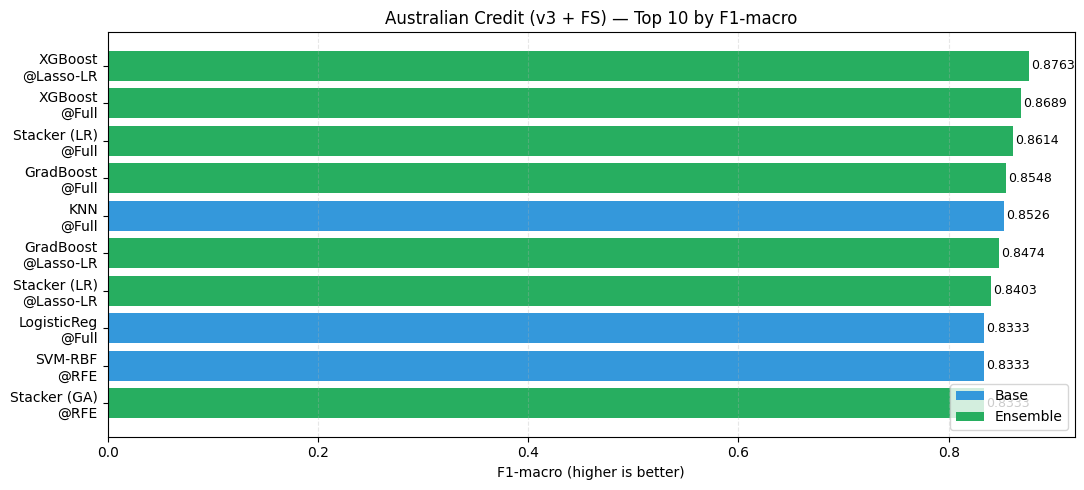

Saved -> /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/results/australian_v3_top10_f1macro.png


In [41]:
top = df_all.head(10).copy()
labels = [f'{m}\n@{fs}' for m, fs in zip(top['Model'], top['FS'])]
colors = {'Base': '#3498db', 'Ensemble': '#27ae60'}
bar_colors = [colors[c] for c in top['Category']]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(range(len(top)), top['F1-macro'], color=bar_colors)
ax.set_yticks(range(len(top))); ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('F1-macro (higher is better)')
ax.set_title('Australian Credit (v3 + FS) — Top 10 by F1-macro')
for i, v in enumerate(top['F1-macro']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3, ls='--')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=colors[k], label=k) for k in colors], loc='lower right')
plt.tight_layout()
plot_path = RESULTS_DIR / f'{RUN_TAG}_top10_f1macro.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {plot_path}')

### §6.4 — Winner declaration

In [42]:
winner = df_all.iloc[0]
print('=' * 70); print('  WINNER on Australian Credit (by F1-macro):'); print('=' * 70)
print(f'  Model:    {winner["Model"]}')
print(f'  Category: {winner["Category"]}')
print(f'  FS:       {winner["FS"]}  ({winner["n_feat"]} features)')
print(f'  Accuracy: {winner["Accuracy"]:.4f}')
print(f'  F1:       {winner["F1"]:.4f}')
print(f'  F1-macro: {winner["F1-macro"]:.4f}')
print(f'  AUC:      {winner["AUC"]:.4f}')
print(f'  thr:      {winner["thr"]:.2f}')

stackers = df_all[df_all['Model'].str.startswith('Stacker')]
non_stacker = df_all[~df_all['Model'].str.startswith('Stacker')]
if len(stackers) and len(non_stacker):
    best_stacker = stackers.iloc[0]
    best_non_stacker = non_stacker.iloc[0]
    margin = best_stacker['F1-macro'] - best_non_stacker['F1-macro']
    print(f'\n  Best Stacker:     {best_stacker["Model"]} @ {best_stacker["FS"]}  F1-macro={best_stacker["F1-macro"]:.4f}')
    print(f'  Best non-stacker: {best_non_stacker["Model"]} @ {best_non_stacker["FS"]}  F1-macro={best_non_stacker["F1-macro"]:.4f}')
    print(f'  Stacker margin:   {margin:+.4f} F1-macro')

  WINNER on Australian Credit (by F1-macro):
  Model:    XGBoost
  Category: Ensemble
  FS:       Lasso-LR  (12 features)
  Accuracy: 0.8768
  F1:       0.8682
  F1-macro: 0.8763
  AUC:      0.9368
  thr:      0.50

  Best Stacker:     Stacker (LR) @ Full  F1-macro=0.8614
  Best non-stacker: XGBoost @ Lasso-LR  F1-macro=0.8763
  Stacker margin:   -0.0149 F1-macro


### §6.5 — Recap of every artefact saved

In [43]:
print('=' * 70); print('  Files saved by this notebook'); print('=' * 70)
for d in [SUBSETS_DIR, RESULTS_DIR]:
    for p in sorted(d.glob(f'{RUN_TAG}*')):
        size = p.stat().st_size
        print(f'  {p}  ({size:,} bytes)')

  Files saved by this notebook
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_Forward.csv  (100,264 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_Forward_features.csv  (51 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_Full.csv  (196,018 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_Full_features.csv  (91 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_Lasso_LR.csv  (168,605 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_Lasso_LR_features.csv  (81 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_RFE.csv  (101,296 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/australian_v3_FS_RFE_features.csv  (50 bytes)
  /co

## §7  Ten-measure evaluation (Chi et al., 2019)

This section adds the **ten credit-scoring measures** — Accuracy, AUC, Type I
error, Type II error, EMCC, G-Mean, Discriminant Power, F-Score, Kappa and
Youden's index — for every model and feature-selection variant.

The earlier model cells (§3, §5) store only Acc / F1 / F1-macro / AUC and
discard the predictions, so each model is **re-fitted here** to recover the full
confusion matrix. Every existing cell above is left unchanged.

### §7.1 — Ten-measure helper `ten_measures()`

In [44]:
# §7.1 -- Ten-measure suite (Chi et al., 2019).  1 = approved (good) = positive.
from sklearn.metrics import confusion_matrix

def ten_measures(y_true, y_pred, proba, cost_bad=5.0, cost_good=1.0):
    """Ten credit-scoring measures from labels + predicted probability."""
    y_true = np.asarray(y_true, int)
    y_pred = np.asarray(y_pred, int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    e = 1e-9
    total = tp + tn + fp + fn
    sens = tp / (tp + fn + e)
    spec = tn / (tn + fp + e)
    prec = tp / (tp + fp + e)
    type1 = fn / (tp + fn + e)
    type2 = fp / (fp + tn + e)
    pi_good = (tp + fn) / (total + e)
    pi_bad  = (tn + fp) / (total + e)
    sc  = min(max(sens, e), 1 - e)
    spc = min(max(spec, e), 1 - e)
    return dict(
        Accuracy = (tp + tn) / (total + e),
        AUC      = roc_auc_score(y_true, proba),
        TypeI    = type1,
        TypeII   = type2,
        EMCC     = cost_bad * pi_bad * type2 + cost_good * pi_good * type1,
        GMean    = np.sqrt(max(sens, 0.0) * max(spec, 0.0)),
        DP       = (np.sqrt(3) / np.pi) * (np.log(sc / (1 - sc))
                                           + np.log(spc / (1 - spc))),
        FScore   = 2 * prec * sens / (prec + sens + e),
        Kappa    = cohen_kappa_score(y_true, y_pred),
        Youden   = sens + spec - 1.0,
    )

print('ten_measures() ready -- Accuracy, AUC, Type I, Type II, EMCC, '
      'G-Mean, DP, F-Score, Kappa, Youden.')

ten_measures() ready -- Accuracy, AUC, Type I, Type II, EMCC, G-Mean, DP, F-Score, Kappa, Youden.


### §7.2 — `evaluate_ten()` and `sweep_ten()` (mirror `evaluate` / `sweep_single_model`)

In [45]:
# §7.2 -- mirror evaluate() / sweep_single_model() from §2, returning ten measures.
def evaluate_ten(model, X_tr, X_te, y_tr, y_te):
    """Fit on (X_tr, y_tr); predict on X_te; return the ten measures + thr.
    Same fit/predict and GHOST threshold logic as evaluate()."""
    model.fit(X_tr, y_tr)
    proba_test = model.predict_proba(X_te)[:, 1]
    if USE_GHOST:
        proba_train = model.predict_proba(X_tr)[:, 1]
        thr = ghostml.optimize_threshold_from_predictions(
            y_tr, proba_train, GHOST_THR, ThOpt_metrics='Kappa')
    else:
        thr = 0.5
    pred = (proba_test >= thr).astype(int)
    r = ten_measures(y_te, pred, proba_test)
    r['thr'] = thr
    return r

def sweep_ten(model_factory, name, category):
    """Run one model_factory across all 4 FS variants -- ten-measure version."""
    rows = []
    for fs_name, fs_idx in fs_methods.items():
        Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
        r = evaluate_ten(model_factory(), Xtr, Xte, y_train, y_test)
        r.update(model=name, category=category, fs=fs_name, n_features=len(fs_idx))
        rows.append(r)
        print(f'  [{category}] {name:<14s} | FS={fs_name:<8s} | '
              f'F-Score={r["FScore"]:.4f}  G-Mean={r["GMean"]:.4f}  '
              f'AUC={r["AUC"]:.4f}  Kappa={r["Kappa"]:.4f}')
    return rows

print('evaluate_ten() and sweep_ten() ready.')

evaluate_ten() and sweep_ten() ready.


### §7.3 — Base models × 4 FS (ten measures)

In [46]:
# §7.3 -- Base models, ten measures (same factories as §3).
base_lr_10 = sweep_ten(
    lambda: maybe_smote(LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
    name='LogisticReg', category='Base')
base_knn_10 = sweep_ten(
    lambda: maybe_smote(KNeighborsClassifier(n_neighbors=13, metric='manhattan')),
    name='KNN', category='Base')
base_svm_10 = sweep_ten(
    lambda: maybe_smote(SVC(C=10.0, kernel='rbf', gamma='scale',
                            probability=True, random_state=RANDOM_STATE)),
    name='SVM-RBF', category='Base')
base_dt_10 = sweep_ten(
    lambda: maybe_smote(DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    name='DecisionTree', category='Base')

  [Base] LogisticReg    | FS=Full     | F-Score=0.8321  G-Mean=0.8390  AUC=0.9140  Kappa=0.6705
  [Base] LogisticReg    | FS=RFE      | F-Score=0.8321  G-Mean=0.8390  AUC=0.9231  Kappa=0.6705
  [Base] LogisticReg    | FS=Lasso-LR | F-Score=0.8321  G-Mean=0.8390  AUC=0.9136  Kappa=0.6705
  [Base] LogisticReg    | FS=Forward  | F-Score=0.8000  G-Mean=0.8024  AUC=0.8456  Kappa=0.6009
  [Base] KNN            | FS=Full     | F-Score=0.8333  G-Mean=0.8508  AUC=0.9074  Kappa=0.7052
  [Base] KNN            | FS=RFE      | F-Score=0.8182  G-Mean=0.8305  AUC=0.8890  Kappa=0.6533
  [Base] KNN            | FS=Lasso-LR | F-Score=0.7840  G-Mean=0.8042  AUC=0.8900  Kappa=0.6054
  [Base] KNN            | FS=Forward  | F-Score=0.8116  G-Mean=0.8171  AUC=0.8510  Kappa=0.6282
  [Base] SVM-RBF        | FS=Full     | F-Score=0.8217  G-Mean=0.8364  AUC=0.8765  Kappa=0.6661
  [Base] SVM-RBF        | FS=RFE      | F-Score=0.8296  G-Mean=0.8387  AUC=0.8933  Kappa=0.6694
  [Base] SVM-RBF        | FS=Lasso-LR | 

### §7.4 — Ensemble models × 4 FS (ten measures)

In [47]:
# §7.4 -- Ensemble models, ten measures (RF and XGB reuse the per-FS tuned models).
ens_rf_10 = []
for fs_name, fs_idx in fs_methods.items():
    Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
    r = evaluate_ten(tuned_rf[fs_name], Xtr, Xte, y_train, y_test)
    r.update(model='RandomForest', category='Ensemble', fs=fs_name, n_features=len(fs_idx))
    ens_rf_10.append(r)
    print(f'  [Ensemble] RandomForest   | FS={fs_name:<8s} | '
          f'F-Score={r["FScore"]:.4f}  G-Mean={r["GMean"]:.4f}  '
          f'AUC={r["AUC"]:.4f}  Kappa={r["Kappa"]:.4f}')

ens_gb_10 = sweep_ten(
    lambda: maybe_smote(GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE)),
    name='GradBoost', category='Ensemble')

ens_xgb_10 = []
for fs_name, fs_idx in fs_methods.items():
    Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
    r = evaluate_ten(tuned_xgb[fs_name], Xtr, Xte, y_train, y_test)
    r.update(model='XGBoost', category='Ensemble', fs=fs_name, n_features=len(fs_idx))
    ens_xgb_10.append(r)
    print(f'  [Ensemble] XGBoost        | FS={fs_name:<8s} | '
          f'F-Score={r["FScore"]:.4f}  G-Mean={r["GMean"]:.4f}  '
          f'AUC={r["AUC"]:.4f}  Kappa={r["Kappa"]:.4f}')

  [Ensemble] RandomForest   | FS=Full     | F-Score=0.8148  G-Mean=0.8241  AUC=0.9306  Kappa=0.6407
  [Ensemble] RandomForest   | FS=RFE      | F-Score=0.8120  G-Mean=0.8236  AUC=0.9176  Kappa=0.6395
  [Ensemble] RandomForest   | FS=Lasso-LR | F-Score=0.8088  G-Mean=0.8170  AUC=0.9295  Kappa=0.6269
  [Ensemble] RandomForest   | FS=Forward  | F-Score=0.8148  G-Mean=0.8241  AUC=0.8884  Kappa=0.6407
  [Ensemble] GradBoost      | FS=Full     | F-Score=0.8485  G-Mean=0.8598  AUC=0.9244  Kappa=0.7111
  [Ensemble] GradBoost      | FS=RFE      | F-Score=0.8271  G-Mean=0.8382  AUC=0.8987  Kappa=0.6683
  [Ensemble] GradBoost      | FS=Lasso-LR | F-Score=0.8397  G-Mean=0.8521  AUC=0.9240  Kappa=0.6962
  [Ensemble] GradBoost      | FS=Forward  | F-Score=0.8062  G-Mean=0.8218  AUC=0.8899  Kappa=0.6371
  [Ensemble] XGBoost        | FS=Full     | F-Score=0.8594  G-Mean=0.8724  AUC=0.9385  Kappa=0.7383
  [Ensemble] XGBoost        | FS=RFE      | F-Score=0.8244  G-Mean=0.8374  AUC=0.9226  Kappa=0.6672


### §7.5 — Stacker × 4 FS (`run_stacker_v3_ten`, ten-measure copy of `run_stacker_v3`)

In [48]:
# §7.5 -- ten-measure copy of run_stacker_v3 (cell in §5b-2). Same 5 bases,
# 5 metas, threshold 0.5, same winning-meta selection (by F1-macro).
def run_stacker_v3_ten(Xtr, Xte, ytr, yte, fs_name):
    print(f'\n  -- Stacker @ FS={fs_name}  (ten-measure eval) --')
    base_models = {
        'RF'  : tuned_rf[fs_name],
        'GB'  : maybe_smote(GradientBoostingClassifier(
                   n_estimators=300, learning_rate=0.05, max_depth=5,
                   subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE)),
        'XGB' : tuned_xgb[fs_name],
        'KNN' : maybe_smote(KNeighborsClassifier(n_neighbors=13, metric='manhattan')),
        'SVM' : maybe_smote(SVC(C=10.0, kernel='rbf', gamma='scale',
                                probability=True, random_state=RANDOM_STATE)),
    }
    oof_cols, test_cols = [], []
    for bname, bmodel in base_models.items():
        oof = cross_val_predict(bmodel, Xtr, ytr, cv=CV_FOLDS,
                                method='predict_proba')[:, 1]
        oof_cols.append(oof)
        bmodel.fit(Xtr, ytr)
        test_cols.append(bmodel.predict_proba(Xte)[:, 1])
    oof_probs  = np.column_stack(oof_cols)
    test_probs = np.column_stack(test_cols)

    best_lam = cv_best_lambda(oof_probs, ytr,
                              lambda_grid=[0.0005, 0.001, 0.002, 0.005, 0.01],
                              cv=5, n_gen=150)
    meta_models = {
        'LR'  : maybe_smote(LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
        'RF'  : maybe_smote(RandomForestClassifier(n_estimators=200, max_depth=5,
                                                   random_state=RANDOM_STATE)),
        'XGB' : maybe_smote(XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                          random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)),
        'MLP' : maybe_smote(MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                                          alpha=0.001, max_iter=500, random_state=RANDOM_STATE)),
        'GA'  : maybe_smote(MaxAccLogit(lambda_reg=best_lam, n_gen=200,
                                        scoring='f1_macro', random_state=RANDOM_STATE)),
    }
    meta_eval = {}
    for mname, meta in meta_models.items():
        meta.fit(oof_probs, ytr)
        proba = meta.predict_proba(test_probs)[:, 1]
        pred  = (proba >= 0.5).astype(int)
        m = ten_measures(yte, pred, proba)
        m['f1_macro'] = f1_score(yte, pred, average='macro')
        meta_eval[mname] = m
        print(f'    meta {mname:<5s}  F-Score={m["FScore"]:.4f}  G-Mean={m["GMean"]:.4f}  '
              f'AUC={m["AUC"]:.4f}  Kappa={m["Kappa"]:.4f}')
    best_meta = max(meta_eval, key=lambda k: meta_eval[k]['f1_macro'])
    r = {k: v for k, v in meta_eval[best_meta].items() if k != 'f1_macro'}
    r['thr'] = 0.5
    r.update(model=f'Stacker ({best_meta})', category='Ensemble',
             fs=fs_name, n_features=Xtr.shape[1])
    print(f'    -> winning meta: {best_meta}  (F-Score={r["FScore"]:.4f})')
    return r

print('run_stacker_v3_ten() ready.')

run_stacker_v3_ten() ready.


In [49]:
# §7.5 -- run the ten-measure stacker once per FS variant.
stk_full_10  = run_stacker_v3_ten(X_train[:, fs_methods['Full']],
                                  X_test[:,  fs_methods['Full']],     y_train, y_test, 'Full')
stk_rfe_10   = run_stacker_v3_ten(X_train[:, fs_methods['RFE']],
                                  X_test[:,  fs_methods['RFE']],      y_train, y_test, 'RFE')
stk_lasso_10 = run_stacker_v3_ten(X_train[:, fs_methods['Lasso-LR']],
                                  X_test[:,  fs_methods['Lasso-LR']], y_train, y_test, 'Lasso-LR')
stk_fwd_10   = run_stacker_v3_ten(X_train[:, fs_methods['Forward']],
                                  X_test[:,  fs_methods['Forward']],  y_train, y_test, 'Forward')


  -- Stacker @ FS=Full  (ten-measure eval) --
    meta LR     F-Score=0.8504  G-Mean=0.8645  AUC=0.9395  Kappa=0.7232
    meta RF     F-Score=0.8154  G-Mean=0.8296  AUC=0.9324  Kappa=0.6522
    meta XGB    F-Score=0.8182  G-Mean=0.8305  AUC=0.9280  Kappa=0.6533
    meta MLP    F-Score=0.8254  G-Mean=0.8417  AUC=0.9410  Kappa=0.6790
    meta GA     F-Score=0.8504  G-Mean=0.8645  AUC=0.9404  Kappa=0.7232
    -> winning meta: LR  (F-Score=0.8504)

  -- Stacker @ FS=RFE  (ten-measure eval) --
    meta LR     F-Score=0.8209  G-Mean=0.8312  AUC=0.9191  Kappa=0.6545
    meta RF     F-Score=0.8235  G-Mean=0.8316  AUC=0.9056  Kappa=0.6556
    meta XGB    F-Score=0.8092  G-Mean=0.8228  AUC=0.8908  Kappa=0.6383
    meta MLP    F-Score=0.8060  G-Mean=0.8166  AUC=0.9225  Kappa=0.6257
    meta GA     F-Score=0.8345  G-Mean=0.8390  AUC=0.9217  Kappa=0.6716
    -> winning meta: GA  (F-Score=0.8345)

  -- Stacker @ FS=Lasso-LR  (ten-measure eval) --
    meta LR     F-Score=0.8333  G-Mean=0.8452  AUC=0

### §7.6 — Ten-measure results table + save CSV

In [50]:
# §7.6 -- combine, sort, display and save the ten-measure results.
all_ten = (base_lr_10 + base_knn_10 + base_svm_10 + base_dt_10
           + ens_rf_10 + ens_gb_10 + ens_xgb_10
           + [stk_full_10, stk_rfe_10, stk_lasso_10, stk_fwd_10])

df_ten = pd.DataFrame(all_ten)[
    ['category', 'model', 'fs', 'n_features',
     'Accuracy', 'AUC', 'TypeI', 'TypeII', 'EMCC',
     'GMean', 'DP', 'FScore', 'Kappa', 'Youden', 'thr']
]
df_ten.columns = ['Category', 'Model', 'FS', 'n_feat',
                  'Accuracy', 'AUC', 'Type I', 'Type II', 'EMCC',
                  'G-Mean', 'DP', 'F-Score', 'Kappa', 'Youden', 'thr']
for c in ['Accuracy', 'AUC', 'Type I', 'Type II', 'EMCC',
          'G-Mean', 'DP', 'F-Score', 'Kappa', 'Youden']:
    df_ten[c] = df_ten[c].round(4)
df_ten['thr'] = df_ten['thr'].round(2)
df_ten = df_ten.sort_values('F-Score', ascending=False).reset_index(drop=True)

print('=' * 110)
print('  §7 TEN-MEASURE EVALUATION -- every model x every FS (sorted by F-Score)')
print('=' * 110)
print(df_ten.to_string(index=False))
print('\nHigher is better EXCEPT Type I, Type II, EMCC (lower is better).')
save_csv(df_ten, RESULTS_DIR / f'{RUN_TAG}_ten_measure_results.csv')

  §7 TEN-MEASURE EVALUATION -- every model x every FS (sorted by F-Score)
Category        Model       FS  n_feat  Accuracy    AUC  Type I  Type II   EMCC  G-Mean     DP  F-Score  Kappa  Youden  thr
Ensemble      XGBoost Lasso-LR      12    0.8768 0.9368  0.0820   0.1558 0.4710  0.8803 2.2634   0.8682 0.7532  0.7622  0.5
Ensemble      XGBoost     Full      14    0.8696 0.9385  0.0984   0.1558 0.4783  0.8724 2.1530   0.8594 0.7383  0.7458  0.5
Ensemble Stacker (LR)     Full      14    0.8623 0.9395  0.1148   0.1558 0.4855  0.8645 2.0579   0.8504 0.7232  0.7294  0.5
Ensemble    GradBoost     Full      14    0.8551 0.9244  0.0820   0.1948 0.5797  0.8598 2.1143   0.8485 0.7111  0.7232  0.5
Ensemble    GradBoost Lasso-LR      12    0.8478 0.9240  0.0984   0.1948 0.5870  0.8521 2.0039   0.8397 0.6962  0.7068  0.5
Ensemble Stacker (GA)      RFE       7    0.8333 0.9217  0.0492   0.2597 0.7464  0.8390 2.2104   0.8345 0.6716  0.6911  0.5
    Base          KNN     Full      14    0.8551 0.9074  0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>